# LayoutLMv3 Demo: Base vs. Fine-Tuned Pipeline Comparison

This notebook demonstrates the difference between the standard LayoutLMv3 base model and your custom fine-tuned model on validation invoices from the `set_eval` folder.

### Pipeline Setup
- **Base Model Inference**: Evaluated on 1 single example invoice.
- **Fine-Tuned Model Inference**: Evaluated on 5 randomly sampled invoices out of the 10 in `set_eval`.
- **Quantitative Metric Evaluation**: Evaluates precision/recall/F1 with spatial **IoU > 60%**.

## Step 0: Shared Setup & Configurations
Import libraries, configure project paths, load label configurations, and define the 10 validation PDFs in `set_eval`.

In [1]:
import os
import sys
import json
import random
import torch
import fitz  # PyMuPDF
import numpy as np
import torch.nn.functional as nnf
import matplotlib.pyplot as plt
from PIL import Image
from transformers import LayoutLMv3Processor, LayoutLMv3TokenizerFast, LayoutLMv3ImageProcessor

# --- ROBUST PATH RESOLUTION ---
CWD = os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(CWD, '..')) if os.path.basename(CWD).lower() == 'report' else CWD
PROJECT_SUBDIR = os.path.join(BASE_DIR, 'Finetuning')

# Append 'src' to system path for trainer and utils
SRC_DIR = os.path.join(PROJECT_SUBDIR, 'src')
if SRC_DIR not in sys.path:
    sys.path.append(SRC_DIR)
from trainer import ModelModule
from utils import dataSetFormat, plot_img

LABEL_CONFIG_PATH = os.path.join(PROJECT_SUBDIR, 'inputs', 'label_config.json')
MODEL_WEIGHTS = os.path.join(PROJECT_SUBDIR, 'src', 'model.bin')
if not os.path.exists(MODEL_WEIGHTS):
    MODEL_WEIGHTS = os.path.join(BASE_DIR, 'model.bin')
BASE_MODEL_NAME = 'microsoft/layoutlmv3-base'

# 1. Define folder and list of all 10 PDFs in set_eval
SET_EVAL_DIR = os.path.join(BASE_DIR, 'set_eval')
ALL_10_PDFS = [
    'invoice_CPC000692500.pdf',
    'invoice_CPI007528982.pdf',
    'invoice_CPI007529614.pdf',
    'invoice_CPI007529621.pdf',
    'invoice_CPI007529644.pdf',
    'invoice_CPI007529709.pdf',
    'invoice_CPI007529714.pdf',
    'invoice_CPI007530918.pdf',
    'invoice_CPI007534847.pdf',
    'invoice_CPI007534955.pdf'
]

# 2. Randomly select 5 out of the 10 files
random.seed(42)
SAMPLED_5_PDFS = random.sample(ALL_10_PDFS, 5)

# Load Labels
with open(LABEL_CONFIG_PATH, 'r') as f:
    config = json.load(f)
id2label = {int(v): k for k, v in config['label2id'].items()}
num_labels = len(id2label)

# Initialize Shared Processor
feature_extractor = LayoutLMv3ImageProcessor(apply_ocr=False)
tokenizer = LayoutLMv3TokenizerFast.from_pretrained(BASE_MODEL_NAME, ignore_mismatched_sizes=True)
processor = LayoutLMv3Processor(tokenizer=tokenizer, image_processor=feature_extractor)

print(f'Set Eval Dir: {SET_EVAL_DIR}')
print(f'All 10 PDFs: {len(ALL_10_PDFS)} files listed.')
print(f'Random 5 Sampled PDFs for FT Inference: {SAMPLED_5_PDFS}')


c:\Users\DELL\.virtualenvs\LayoutLMv3-gMFc_kGI\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[2026-08-03 15:13:36,645] [ WARNING] _http.py:916 - Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


Set Eval Dir: d:\Internship\Invoice Intelligence Document\LayoutLMv3\set_eval
All 10 PDFs: 10 files listed.
Random 5 Sampled PDFs for FT Inference: ['invoice_CPI007528982.pdf', 'invoice_CPC000692500.pdf', 'invoice_CPI007529644.pdf', 'invoice_CPI007534955.pdf', 'invoice_CPI007529714.pdf']


In [ ]:
def convert_pdf_to_images(pdf_path, dpi=300):
    """Converts a PDF file to a list of PIL Images."""
    doc = fitz.open(pdf_path)
    zoom = dpi / 72
    mat = fitz.Matrix(zoom, zoom)
    images = []
    for page in doc:
        pix = page.get_pixmap(matrix=mat)
        img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
        images.append(img)
    doc.close()
    return images

def run_prediction(image, model, processor, id2label, conf_threshold=0.25):
    """Core LayoutLMv3 prediction logic with confidence filtering (> 0.25)."""
    test_dict, w_scale, h_scale = dataSetFormat(image)
    encoding = processor(image, test_dict["tokens"], boxes=test_dict["bboxes"], 
                         max_length=512, stride=128, padding="max_length", truncation=True, 
                         return_overflowing_tokens=True, return_offsets_mapping=True, return_tensors="pt")
    
    final_predictions = {}
    for i in range(len(encoding.input_ids)):
        with torch.no_grad():
            inputs = {k: encoding[k][i].unsqueeze(0) for k in ["input_ids", "attention_mask", "bbox", "pixel_values"]}
            logits, _ = model(**inputs)
            probs = nnf.softmax(logits.squeeze(0), dim=-1).numpy()
            labels = logits.argmax(dim=-1).squeeze().tolist()
            for idx, word_id in enumerate(encoding.word_ids(i)):
                if word_id is None or encoding["offset_mapping"][i][idx][0] != 0: continue
                label_id, prob = labels[idx], probs[idx][labels[idx]]
                if word_id not in final_predictions or prob > final_predictions[word_id]["prob"]:
                    final_predictions[word_id] = {"label_id": label_id, "prob": prob, "box": encoding["bbox"][i][idx].tolist(), "text": test_dict["tokens"][word_id]}
    
    # Filter prediction results where confidence > conf_threshold (0.25)
    results = [{"label": id2label.get(p["label_id"], "O"), "confidence": float(p["prob"]), "text": p["text"], "box": p["box"]} 
               for word_id, p in sorted(final_predictions.items()) 
               if id2label.get(p["label_id"], "O") != "O" and float(p["prob"]) > conf_threshold]
    return results, w_scale, h_scale


---
## Pipeline A: Base Model Inference (1 Single Example)
Demonstrates the untrained LayoutLMv3 base model on **1 single example PDF** from `set_eval`.

Initializing Base Model...


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 3546.17it/s]
LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight         | MISSING    | 
classifier.dense.weight            | MISSING    | 
classifier.out_proj.bias           | MISSING    | 
classifier.dense.bias              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running Base Model on 1 Example PDF: invoice_CPI007528982.pdf...
[2026/08/03 15:16:23] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='C:\\Users\\DELL/.paddleocr/whl\\det\\en\\en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='C:\\Users\\DELL/.paddleocr/whl\\rec\\en\\en_PP-OCRv4_rec_infer', rec_image_inverse=Tr

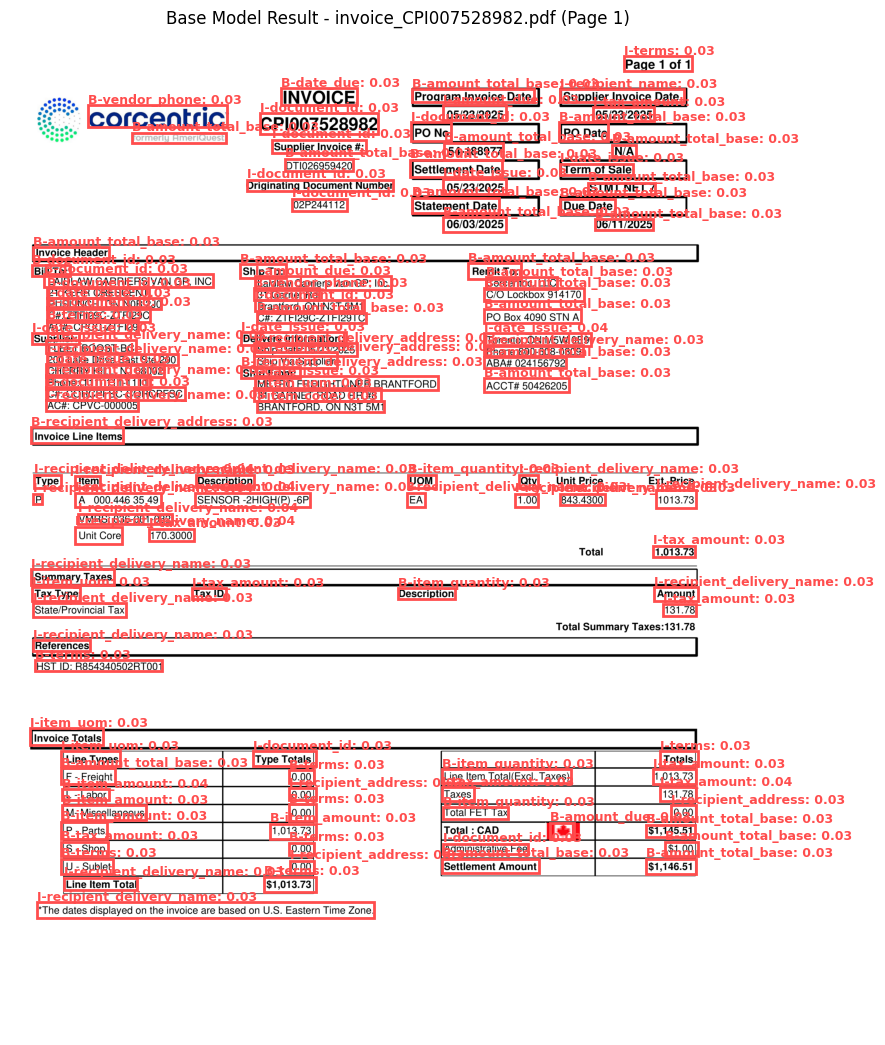

In [3]:
print("Initializing Base Model...")
base_model = ModelModule(num_labels)
base_model.eval()

# Run base model on 1 single example PDF
single_pdf_path = os.path.join(SET_EVAL_DIR, SAMPLED_5_PDFS[0])
print(f"Running Base Model on 1 Example PDF: {SAMPLED_5_PDFS[0]}...")
pages = convert_pdf_to_images(single_pdf_path)

for i, page_img in enumerate(pages):
    res, w, h = run_prediction(page_img, base_model, processor, id2label, conf_threshold=0)
    plt.figure(figsize=(10, 15))
    plt.imshow(page_img)
    ax = plt.gca()
    
    for r in res:
        x1, y1 = r['box'][0]*w/1000, r['box'][1]*h/1000
        wb, hb = (r['box'][2]-r['box'][0])*w/1000, (r['box'][3]-r['box'][1])*h/1000
        light_red = '#ff4d4d'
        ax.add_patch(plt.Rectangle((x1, y1), wb, hb, linewidth=2, edgecolor=light_red, facecolor='none'))
        ax.text(x1, y1 - 5, f"{r['label']}: {r['confidence']:.2f}", fontsize=9, color=light_red, fontweight='bold')
        
    plt.title(f"Base Model Result - {SAMPLED_5_PDFS[0]} (Page {i+1})")
    plt.axis('off')
    plt.show()


---
## Pipeline B: Fine-Tuned Model Inference (Random 5 out of 10 PDFs)
Runs the custom fine-tuned LayoutLMv3 model on **all 5 randomly selected validation PDFs** from `set_eval`.

Initializing Fine-Tuned Model...


Loading weights: 100%|██████████| 212/212 [00:00<00:00, 4122.19it/s]
LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight         | MISSING    | 
classifier.dense.weight            | MISSING    | 
classifier.out_proj.bias           | MISSING    | 
classifier.dense.bias              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



[1/5] Processing invoice_CPI007528982.pdf...
[2026/08/03 15:19:17] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/08/03 15:19:18] ppocr DEBUG: dt_boxes num : 121, elapsed : 0.16829371452331543
[2026/08/03 15:19:22] ppocr DEBUG: rec_res num  : 121, elapsed : 3.9132211208343506


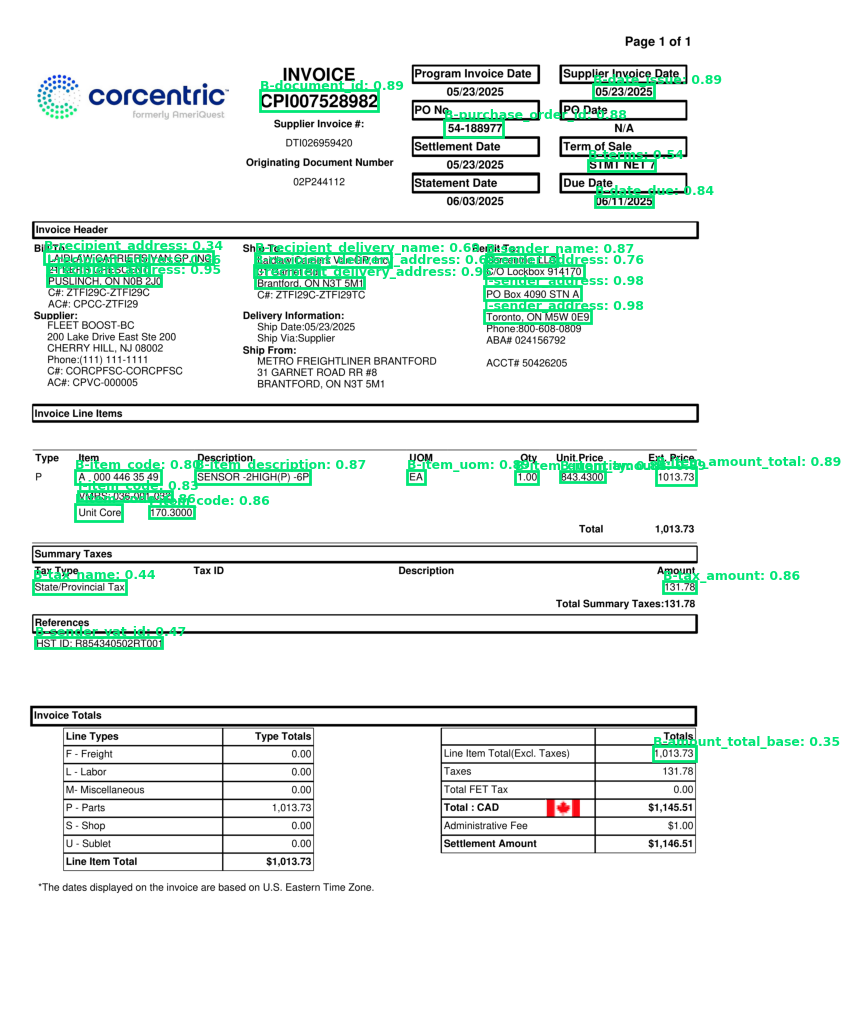


[2/5] Processing invoice_CPC000692500.pdf...
[2026/08/03 15:19:27] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/08/03 15:19:27] ppocr DEBUG: dt_boxes num : 131, elapsed : 0.3429837226867676
[2026/08/03 15:19:32] ppocr DEBUG: rec_res num  : 131, elapsed : 4.545345067977905


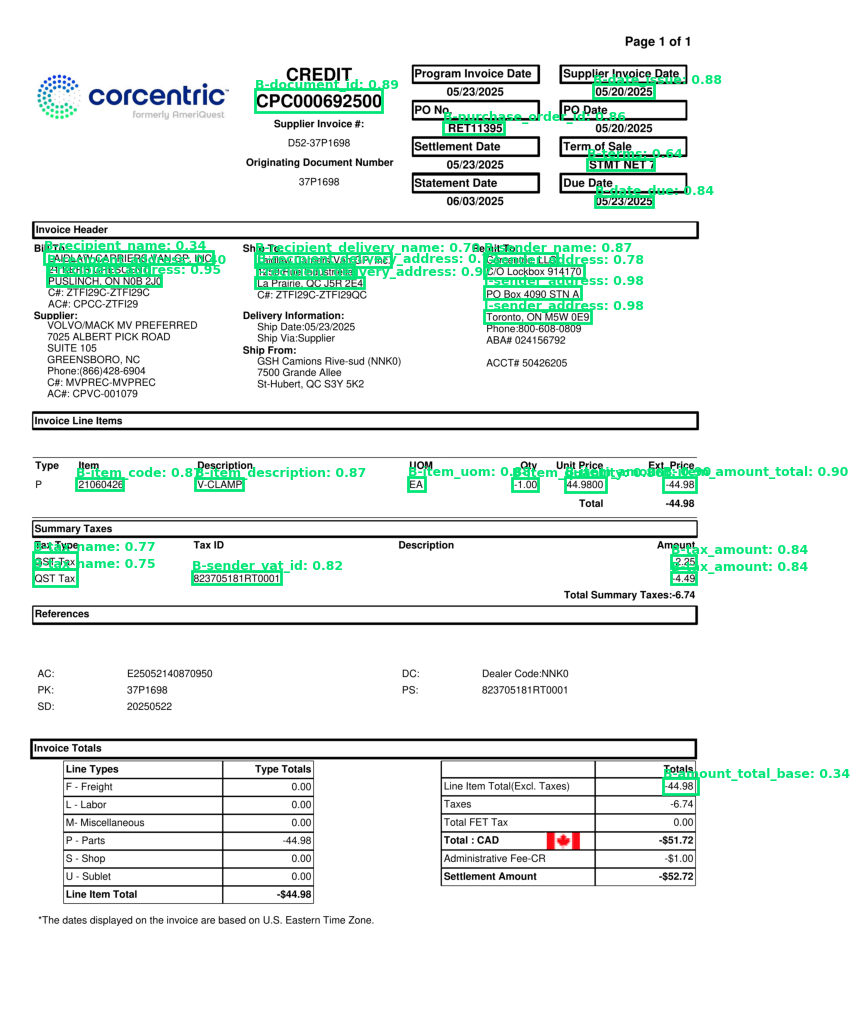


[3/5] Processing invoice_CPI007529644.pdf...
[2026/08/03 15:19:37] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/08/03 15:19:37] ppocr DEBUG: dt_boxes num : 134, elapsed : 0.17168879508972168
[2026/08/03 15:19:42] ppocr DEBUG: rec_res num  : 134, elapsed : 4.831143379211426


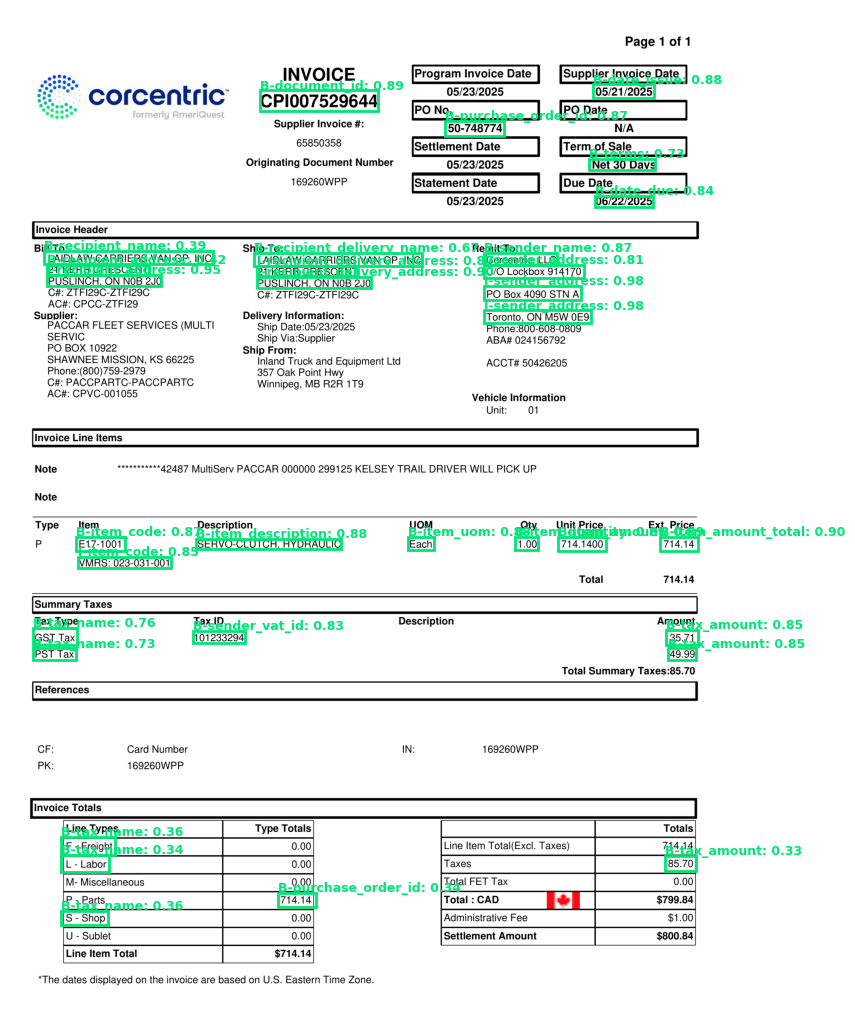


[4/5] Processing invoice_CPI007534955.pdf...
[2026/08/03 15:19:47] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/08/03 15:19:48] ppocr DEBUG: dt_boxes num : 139, elapsed : 0.3609180450439453
[2026/08/03 15:19:53] ppocr DEBUG: rec_res num  : 139, elapsed : 5.047554969787598


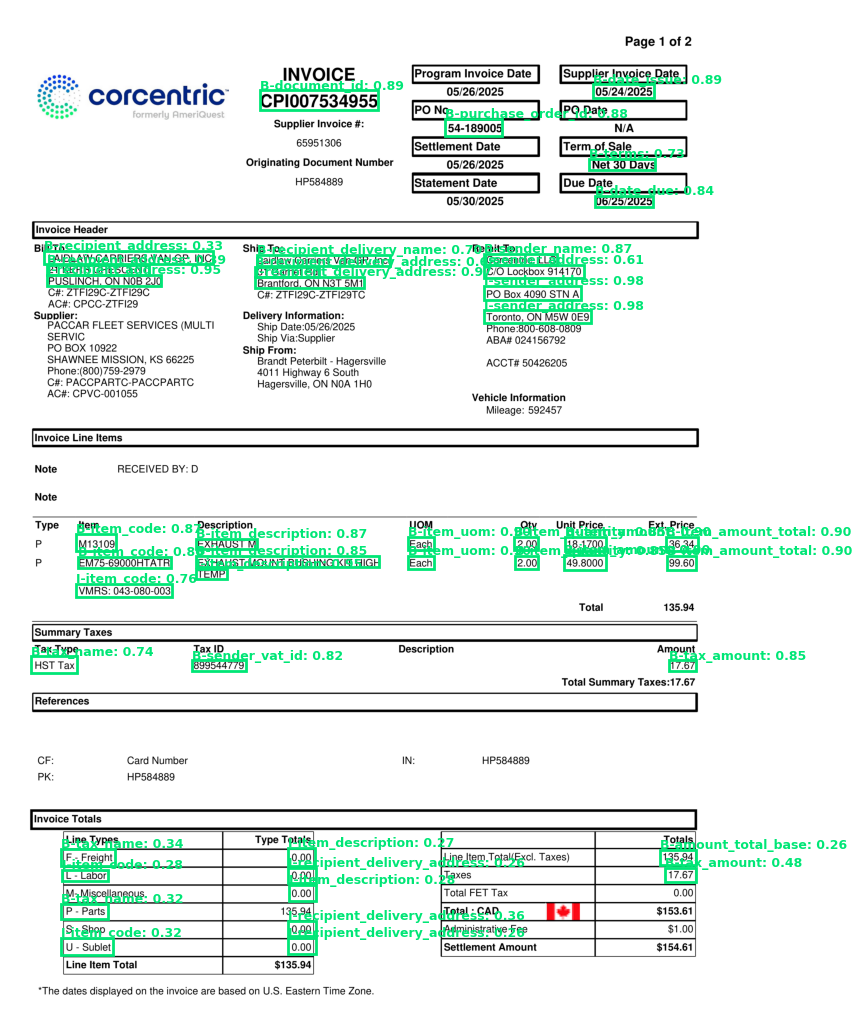


[5/5] Processing invoice_CPI007529714.pdf...
[2026/08/03 15:19:58] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
[2026/08/03 15:19:58] ppocr DEBUG: dt_boxes num : 128, elapsed : 0.18813157081604004
[2026/08/03 15:20:03] ppocr DEBUG: rec_res num  : 128, elapsed : 4.705986261367798


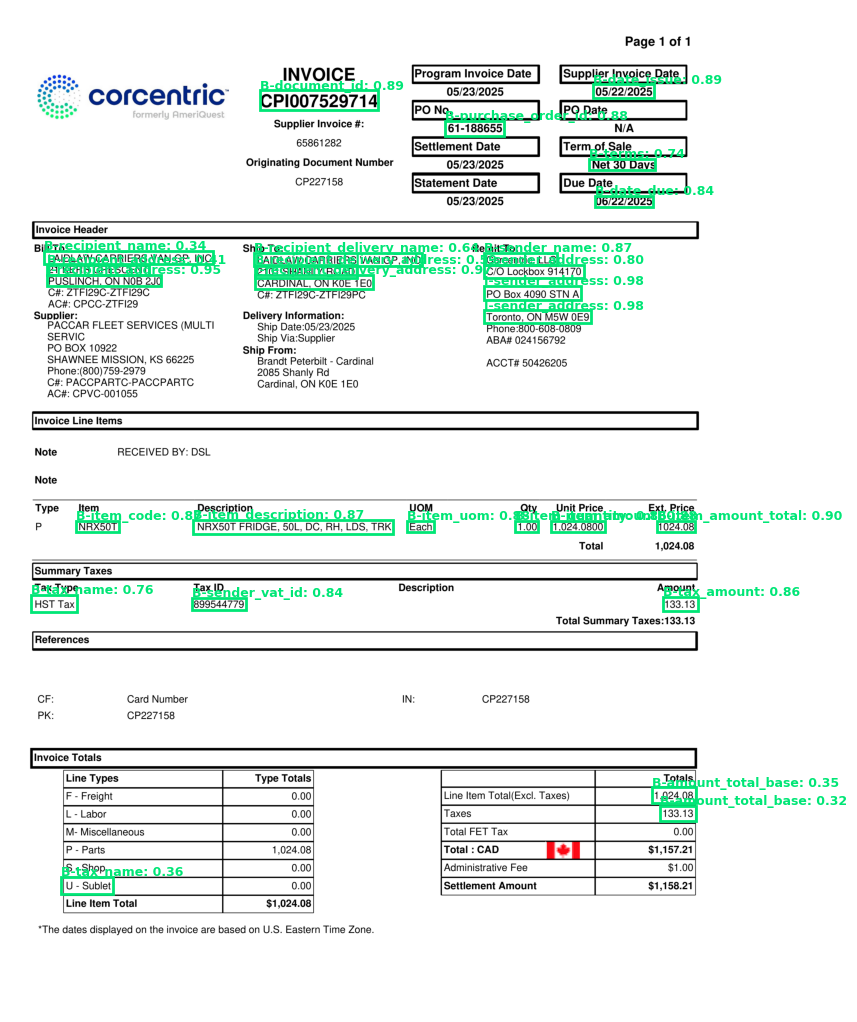

In [ ]:
print("Initializing Fine-Tuned Model...")
ft_model = ModelModule(num_labels)
ft_model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location="cpu"), strict=False)
ft_model.eval()

CONF_THRESHOLD = 0.25
for idx, pdf_name in enumerate(SAMPLED_5_PDFS):
    pdf_path = os.path.join(SET_EVAL_DIR, pdf_name)
    print(f"\n[{idx+1}/5] Processing {pdf_name}...")
    pages = convert_pdf_to_images(pdf_path)
    
    for i, page_img in enumerate(pages):
        res, w, h = run_prediction(page_img, ft_model, processor, id2label, conf_threshold=0.25)
        plt.figure(figsize=(10, 15))
        plt.imshow(page_img)
        ax = plt.gca()
        
        for r in res:
            x1, y1 = r['box'][0]*w/1000, r['box'][1]*h/1000
            wb, hb = (r['box'][2]-r['box'][0])*w/1000, (r['box'][3]-r['box'][1])*h/1000
            green = '#00e676'
            ax.add_patch(plt.Rectangle((x1, y1), wb, hb, linewidth=2, edgecolor=green, facecolor='none'))
            ax.text(x1, y1 - 5, f"{r['label']}: {r['confidence']:.2f}", fontsize=9, color=green, fontweight='bold')
        plt.axis('off')
        plt.show()
